## DSAN 5650 Workshop 4: Introduction to PyMC

In lecture this week we started by looking at the following PGM, which "lays out" in explicit form many of the implicit assumptions that R's `lm()` or Python's `statsmodels.ols()` make when you as it to carry out a regression – so, what better way to start learning PyMC than to open it up and start learning how to "re-implement" standard linear regression, but now within a full **modeling language** that will then allow you to change any parameters you'd like!

<center>

<img src='https://raw.githubusercontent.com/jpowerj/dsan-content/196da73d343c2bc632c0d580d172f3cd5828542c/2026-sum-dsan5650/workshop01/pgm_regression.svg' style='width: 50%; margin: auto;'>

</center>

And, one benefit of having a custom Coding Workshop just for this class is that, we can also choose a **dataset** that will help you get comfortable with Computational *Social Science* while you learn `PyMC` :) Specifically, we'll be using a dataset from Nunn and Wantchekon (2011), ["The Slave Trade and the Origins of Mistrust in Africa"](https://www.aeaweb.org/articles?id=10.1257%2Faer.101.7.3221&utm), which is interesting on its own terms but also gives us an introduction to the [**Afrobarometer**](https://www.afrobarometer.org/) dataset that you'll be diving into for HW2.

## 1 Loading the Data

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

import pymc as pm
import arviz as az
import xarray as xr
import preliz as pz

In [50]:
nunn_data_url = "https://github.com/jpowerj/dsan-content/raw/refs/heads/main/2026-sum-dsan5650/workshop01/slave_trade_QJE.dta"
country_df = pd.read_stata(nunn_data_url)
country_df.head()

,isocode,country,ln_maddison_pcgdp2000,ln_export_area,ln_export_pop,colony0,colony1,colony2,colony3,colony4,...,ln_avg_oil_pop,ln_avg_all_diamonds_pop,ln_pop_dens_1400,atlantic_distance_minimum,indian_distance_minimum,saharan_distance_minimum,red_sea_distance_minimum,ethnic_fractionalization,state_dev,land_area
0,AGO,Angola,6.670766,7.967494,14.399250,0.0,0.0,0.0,1.0,0.0,...,0.643126,-1.701396,-0.024917,5.668760,6.980571,4.925892,3.872354,0.7867,0.635,1.2500
1,BDI,Burundi,6.354370,1.140843,4.451658,0.0,0.0,0.0,0.0,1.0,...,-9.210340,-6.907755,3.036856,10.626214,2.570375,3.718742,2.215324,0.2951,0.995,0.0278
2,BEN,Benin,7.187657,8.304137,13.308970,0.0,0.0,1.0,0.0,0.0,...,-3.531555,-6.907755,1.214196,5.120652,9.233961,2.834785,3.901736,0.7872,0.695,0.1130
3,BFA,Burkina Faso,6.748760,6.413822,11.724286,0.0,0.0,1.0,0.0,0.0,...,-9.210340,-6.907755,0.908565,4.774938,9.299419,2.763519,4.239375,0.7377,0.338,0.2740
4,BWA,Botswana,8.377471,-2.302585,3.912023,0.0,1.0,0.0,0.0,0.0,...,-9.210340,2.186849,-2.075029,5.686335,5.764575,5.856533,4.299600,0.4102,0.893,0.6000


In [51]:
country_df.columns

Index(['isocode', 'country', 'ln_maddison_pcgdp2000', 'ln_export_area',
       'ln_export_pop', 'colony0', 'colony1', 'colony2', 'colony3', 'colony4',
       'colony5', 'colony6', 'colony7', 'abs_latitude', 'longitude',
       'rain_min', 'humid_max', 'low_temp', 'ln_coastline_area', 'island_dum',
       'islam', 'legor_fr', 'legor_uk', 'region_n', 'region_s', 'region_w',
       'region_e', 'region_c', 'ln_avg_gold_pop', 'ln_avg_oil_pop',
       'ln_avg_all_diamonds_pop', 'ln_pop_dens_1400',
       'atlantic_distance_minimum', 'indian_distance_minimum',
       'saharan_distance_minimum', 'red_sea_distance_minimum',
       'ethnic_fractionalization', 'state_dev', 'land_area'],
      dtype='str')

## 2 "Off-the-Shelf" Regression with `statsmodels`

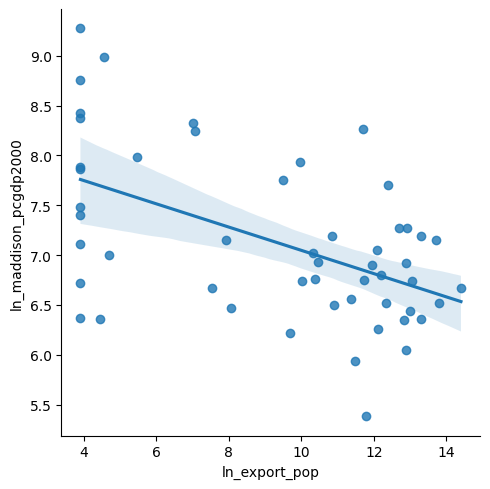

In [4]:
sns.lmplot(
  x='ln_export_pop', y='ln_maddison_pcgdp2000',
  data=country_df
);
plt.show()

In [5]:
gdp_model_sm = smf.ols('ln_maddison_pcgdp2000 ~ ln_export_pop', data=country_df).fit()
gdp_model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     ln_maddison_pcgdp2000   R-squared:                       0.271
Model:                               OLS   Adj. R-squared:                  0.257
Method:                    Least Squares   F-statistic:                     18.62
Date:                   Fri, 12 Jun 2026   Prob (F-statistic):           7.52e-05
Time:                           19:01:34   Log-Likelihood:                -55.065
No. Observations:                     52   AIC:                             114.1
Df Residuals:                         50   BIC:                             118.0
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         8.2151      0.269     30.499      0.000       7.674       8.756
ln_export_pop    -0.1168      0.027     -4.315      0.000      -0.171      -0.062
==============================================================================
Omnibus:                        0.176   Durbin-Watson:                   2.527
Prob(Omnibus):                  0.916   Jarque-Bera (JB):                0.376
Skew:                           0.058   Prob(JB):                        0.829
Kurtosis:                       2.600   Cond. No.                         27.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 2.1 What Do We Get? ...A Point Estimate of the Mean, and a Point Estimate of Uncertainty

,Feature,Coefficient,Lower_CI,Upper_CI
0,Intercept,8.215094,7.674079,8.756109
1,ln_export_pop,-0.116754,-0.171097,-0.062410


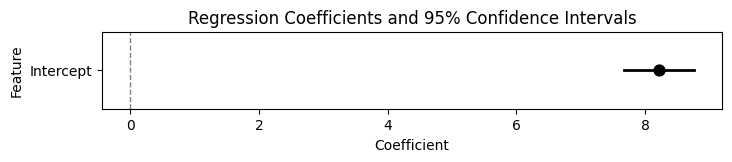

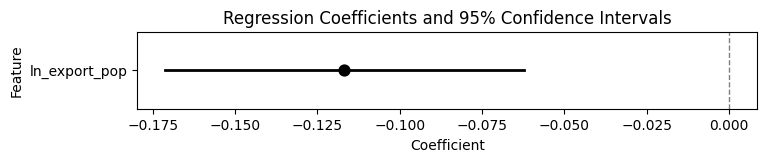

In [6]:
# 3. Plot coefficients and 95% Confidence Intervals
param_df = gdp_model_sm.params.reset_index()
param_df.columns = ['Feature', 'Coefficient']
param_df = param_df.set_index('Feature')
# display(param_df)
conf_df = gdp_model_sm.conf_int()
conf_df.columns = ['Lower_CI', 'Upper_CI']
# display(conf_df)

full_coef_df = pd.concat([param_df, conf_df], axis=1).reset_index() \
  .rename(columns={'index': 'Feature'})
display(full_coef_df)

def plot_coefs(coef_df):
  plt.figure(figsize=(8, 1))
  sns.pointplot(
    data=coef_df, 
    x='Coefficient', 
    y='Feature',
    linestyle='none',
    errorbar=None,
    markers='o', 
    color='black'
  )
  # Manually add confidence intervals
  for idx, row in coef_df.reset_index().iterrows():
    plt.plot(
      [row['Lower_CI'], row['Upper_CI']], 
      [idx, idx], 
      color='black', 
      linewidth=2
    )
  # Vertical line representing 0 (no effect)
  plt.axvline(0, color='gray', linestyle='--', linewidth=1)
  plt.title('Regression Coefficients and 95% Confidence Intervals')
  plt.show()

# Plot intercept
plot_coefs(full_coef_df[full_coef_df['Feature'] == 'Intercept'])
# Plot effect
b1_df = full_coef_df[full_coef_df['Feature'] == 'ln_export_pop'].copy()
plot_coefs(b1_df)

I know it's difficult if your brain has been trained to think that this is "the" information you can learn about the world from a regression, but try to think of the underlying scenarios that might be "masked" by the fact that we can only view a single point estimate (the dot) and a single uncertainty estimate (the width of the lines on either side of the dot). For example: is -0.117 actually the "most likely" value of the coefficient? Or, could this arise from a case where there are two "humps" in our distribution, at (say) -0.1 and -0.14, that "average out" to -0.117...

Another issue is... less mathematical and more interpretive, but also maybe more important: from your introductory stats class onwards, you have to constantly be reminded that **a 95% confidence interval does *not* mean an interval with 95% probability of containing the true value!** Instead, you have to constantly tamp down your intuition, and remember some strange statement about how "if you repeated the sampling procedure infinitely many times, 95% of those times the resulting interval would contain this parameter value". Well, bucko, get excited because you won't need to do that anymore with a **Bayesian model** like the ones you'll be implementing here in PyMC!

**By explicitly placing a *prior* probability on each parameter, you obtain a natural/intuitive implicational statement: *"Given this prior, in combination with the data, there is a 95% chance that the true value is between $x$ and $y$"***

With the powerful **computational tools** we have at our disposal (multicore processors, parallelization, neural networks, etc.), we don't have to "settle" for just two pieces of information about the intercept and the effect of slave exports, and we don't have to "settle" for the default "flat priors" that then require weird statements about infinitely repeating sampling procedures. We can use these tools to estimate the **full distribution of our uncertainty about these values**, which is exactly what **`PyMC`** enables, by keeping full mathematical representations of both our **prior knowledge** (our distribution of likely parameter values *before* looking at the data) and **posterior knowledge** (our distribution of likely parameter values *after* looking at the data).

## 4 "Customizable" Regression with PyMC

In [54]:
import pymc as pm

gdp_coords = {
  'country': list(range(len(country_df))),
}
print(gdp_coords)

{'country': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51]}


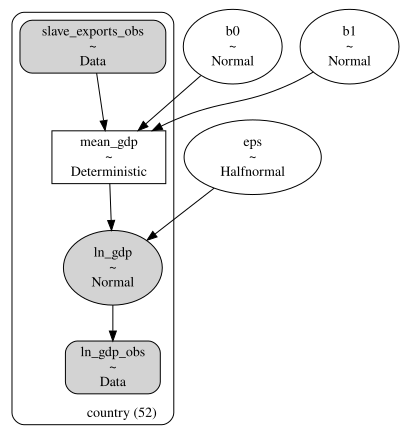

In [60]:
with pm.Model(coords=gdp_coords) as gdp_model:
  # Observed Data
  slave_exports_obs = pm.Data(
    "slave_exports_obs",
    country_df['ln_export_pop'],
    dims='country',
  )
  ln_gdp_obs = pm.Data(
    "ln_gdp_obs",
    country_df['ln_maddison_pcgdp2000'],
    dims='country',
  )
  # X, Y nodes set up in PyMC

  # Parameters
  b0 = pm.Normal('b0', mu=8, sigma=0.5)
  b1 = pm.Normal('b1', mu=0, sigma=0.5)
  eps = pm.HalfNormal('eps', sigma=4)

  # Linking them together!
  mean_ln_gdp = pm.Deterministic(
    'mean_gdp',
    b0 + b1 * slave_exports_obs,
    dims='country',
  )
  ln_gdp = pm.Normal(
    'ln_gdp',
    mu=mean_ln_gdp, sigma=eps,
    observed=ln_gdp_obs,
    dims='country',
  )

gdp_model.to_graphviz()

In [62]:
with gdp_model:
  idata = pm.sample(num_draws=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, b1, eps]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [63]:
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:   (chain: 4, draw: 1000, country: 52)
│       Coordinates:
│         * chain     (chain) int64 32B 0 1 2 3
│         * draw      (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * country   (country) int64 416B 0 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50 51
│       Data variables:
│           b0        (chain, draw) float64 32kB 8.03 8.473 8.28 ... 8.215 8.086 8.127
│           b1        (chain, draw) float64 32kB -0.1094 -0.1458 ... -0.1042 -0.1067
│           eps       (chain, draw) float64 32kB 0.7539 0.7357 0.6884 ... 0.7615 0.6839
│           mean_gdp  (chain, draw, country) float64 2MB 6.454 7.543 ... 6.965 7.282
│       Attributes:
│           created_at:                 2026-06-12T21:15:10.022915+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1.5778107643127441
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           perf_counter_start     (chain, draw) float64 32kB 2.496e+06 ... 2.496e+06
│           index_in_trajectory    (chain, draw) int64 32kB 1 3 -6 -3 3 ... -1 -2 -3 2
│           tree_depth             (chain, draw) int64 32kB 3 4 3 4 4 3 ... 2 2 2 4 3 3
│           divergences            (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           step_size              (chain, draw) float64 32kB 0.3604 0.3604 ... 0.2844
│           energy                 (chain, draw) float64 32kB 61.48 59.98 ... 58.59
│           ...                     ...
│           reached_max_treedepth  (chain, draw) bool 4kB False False ... False False
│           lp                     (chain, draw) float64 32kB -58.42 -58.63 ... -57.68
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│           energy_error           (chain, draw) float64 32kB 0.3076 ... -0.01318
│           max_energy_error       (chain, draw) float64 32kB 0.5392 -0.2722 ... 0.03184
│           diverging              (chain, draw) bool 4kB False False ... False False
│       Attributes:
│           created_at:                 2026-06-12T21:15:10.039303+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1.5778107643127441
│           tuning_steps:               1000
├── Group: /observed_data
│       Dimensions:  (country: 52)
│       Coordinates:
│         * country  (country) int64 416B 0 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50 51
│       Data variables:
│           ln_gdp   (country) float64 416B 6.671 6.354 7.188 ... 5.384 6.501 7.155
│       Attributes:
│           created_at:                 2026-06-12T21:15:10.044352+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.0
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:            (country: 52)
        Coordinates:
          * country            (country) int64 416B 0 1 2 3 4 5 6 ... 46 47 48 49 50 51
        Data variables:
            slave_exports_obs  (country) float64 416B 14.4 4.452 13.31 ... 10.89 7.925
        Attri

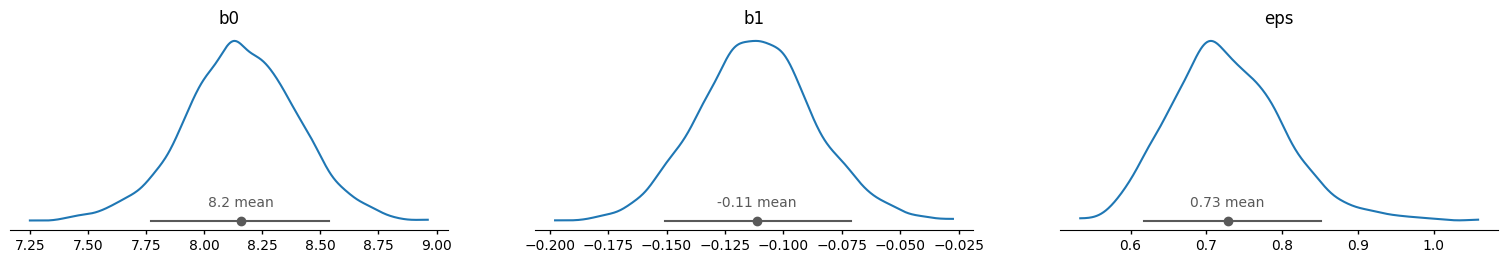

In [64]:
az.plot_dist(
  idata.posterior,
  var_names=['b0','b1', 'eps'],
);
plt.show()

In [11]:
b0_mean = float(idata.posterior['b0'].mean())
b1_mean = float(idata.posterior['b1'].mean())
b0_mean, b1_mean

(8.161833487707938, -0.11172543274908432)

In [12]:
az.summary(idata.posterior, var_names=['b0', 'b1', 'eps'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0,8.16,0.237,7.8,8.5,1447,1666,1.00,0.0063,0.0047
b1,-0.112,0.024,-0.15,-0.073,1466,1672,1.00,0.00064,0.0005
eps,0.724,0.075,0.62,0.85,2043,1992,1.00,0.0017,0.0014


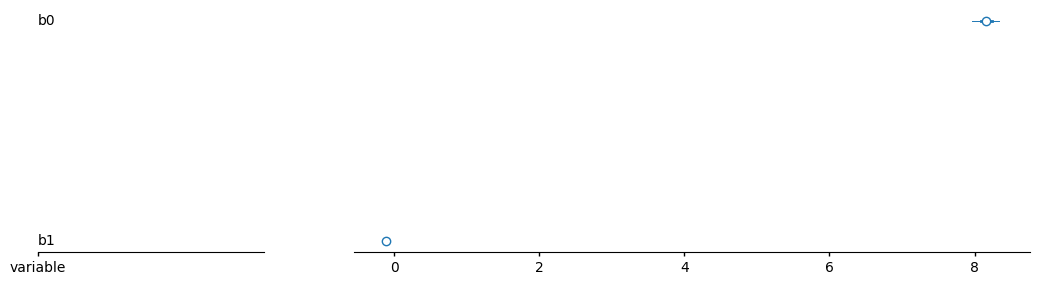

In [13]:
az.plot_forest(idata.posterior.mean('chain'), var_names=['b0', 'b1']);
plt.show()

In [14]:
print(idata.posterior['b0'].quantile((.025, .975), dim=("chain", "draw")))
print(idata.posterior['b1'].quantile((.025, .975), dim=("chain", "draw")))

<xarray.DataArray 'b0' (quantile: 2)> Size: 16B
array([7.68464826, 8.61926868])
Coordinates:
  * quantile  (quantile) float64 16B 0.025 0.975
<xarray.DataArray 'b1' (quantile: 2)> Size: 16B
array([-0.15813826, -0.06430003])
Coordinates:
  * quantile  (quantile) float64 16B 0.025 0.975


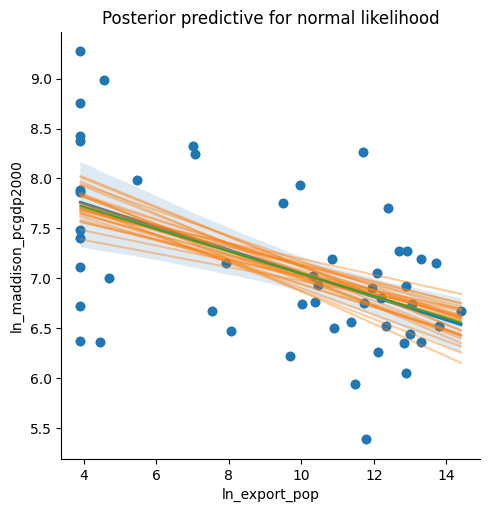

In [16]:
post = az.extract(idata.posterior, num_samples=30)
x_plot = xr.DataArray(
  np.linspace(
    country_df['ln_export_pop'].min(),
    country_df['ln_export_pop'].max(),
    100
  ),
  dims="plot_id"
)
lines = post["b0"] + post["b1"] * x_plot
lines2 = b0_mean + b1_mean * x_plot

sns.lmplot(
  x='ln_export_pop', y='ln_maddison_pcgdp2000',
  data=country_df
);
plt.scatter(country_df['ln_export_pop'], country_df['ln_maddison_pcgdp2000'], label="data")
plt.plot(x_plot, lines.transpose(), alpha=0.4, color="C1")
plt.plot(x_plot, lines2.transpose(), alpha=0.9, color='C2')
plt.title("Posterior predictive for normal likelihood");
plt.show()

## 4 Prior Checks

How tf did we decide what prior to choose? The answer is... very carefully! Let's bring in `PreliZ`

In [17]:
with gdp_model:
  idata_pr = pm.sample_prior_predictive(draws=300)

Sampling: [b0, b1, eps, ln_gdp]


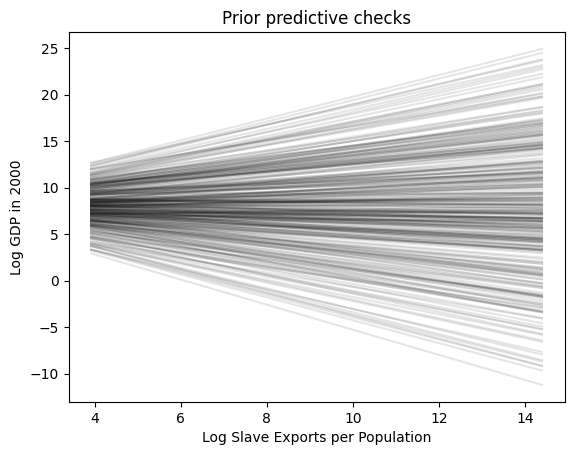

In [20]:
_, ax = plt.subplots()

x = xr.DataArray(
  np.linspace(country_df['ln_export_pop'].min(), country_df['ln_export_pop'].max(), 50),
  dims=["plot_dim"]
)
y = idata_pr.prior["b0"] + idata_pr.prior["b1"] * x

ax.plot(x, y.stack(sample=("chain", "draw")), c="k", alpha=0.1)

ax.set_xlabel("Log Slave Exports per Population")
ax.set_ylabel("Log GDP in 2000")
ax.set_title("Prior predictive checks");


This brings up something a bit... subtle but important about how you can start thinking in a PyMC way rather than an... R or Statsmodels way (though in R, you can use Stan or Ulam instead of PyMC! So if you are an **R** aficionado, this would be "thinking in a Stan rather than `lm` way"): since we are learning a **language** that will allow us to parameterize our models however we'd like, we can think of how we might **customize** this setup to **help us in our modeling task**: in other words, having the model "work for us" rather than trying to adapt our thinking to the model!

Specifically, what I'm referring to here is the fact that **choosing a prior for $\beta_0$ means specifying an "initial guess" (plus an uncertainty about that initial guess) for a *country with exactly one slave exported*** (since $\ln(x) = 0 \iff x = 1$). Think about how this might be a strange "though experiment" for a researcher trying to understand the impact of slave exports on GDP: they may have expertise on essentially the trajectory of the "average" African country's history from the era of the Atlantic Slave Trade to the present... and yet in `statsmodels`, by forcing them to model the **intercept** here, forces them to have to model a case that is by definition the most extreme possible outlier (since number of slaves exported can't be less than 1 given the model setup).

And, it gets worse! Those of you who have studied house prices, for example, may have had to estimate a regression modeling how the square footage of a house impacts its price. Modeling the intercept in that case means trying to imagine what **a house with 0 square feet** might sell for on the housing market...

To avoid this, let's now just make a slight modification to our PyMC model from above to enable us to do what is **much more natural for us as social-scientific modelers: modeling the *average* or "most typical" unit of observation!**

## 5 Posterior Predictive Checks

In [21]:
with gdp_model:
  pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [ln_gdp]


Output()

In [65]:
idata.posterior

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:   (chain: 4, draw: 1000, country: 52)
    Coordinates:
      * chain     (chain) int64 32B 0 1 2 3
      * draw      (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
      * country   (country) int64 416B 0 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50 51
    Data variables:
        b0        (chain, draw) float64 32kB 8.03 8.473 8.28 ... 8.215 8.086 8.127
        b1        (chain, draw) float64 32kB -0.1094 -0.1458 ... -0.1042 -0.1067
        eps       (chain, draw) float64 32kB 0.7539 0.7357 0.6884 ... 0.7615 0.6839
        mean_gdp  (chain, draw, country) float64 2MB 6.454 7.543 ... 6.965 7.282
    Attributes:
        created_at:                 2026-06-12T21:15:10.022915+00:00
        creation_library:           ArviZ
        creation_library_version:   1.1.0
        creation_library_language:  Python
        inference_library:          pymc
        inference_library_version:  6.0.0
        sample_dims:                ['chain', 'draw']
        sampling_time:              1.5778107643127441
        tuning_steps:               1000

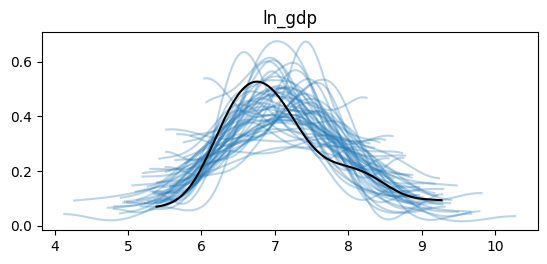

In [22]:
az.plot_ppc_dist(idata, num_samples=50, kind='kde');
plt.show()

In [28]:
post_pred_draws = idata.posterior_predictive['ln_gdp'].mean('chain')

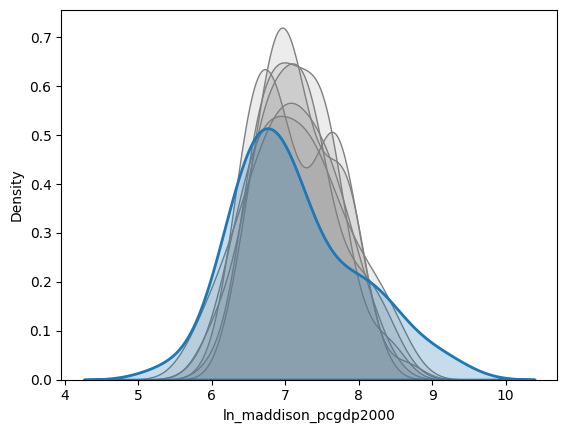

In [49]:
for cur_draw in post_pred_draws[:6]:
  sns.kdeplot(
    cur_draw,
    fill=True, alpha=0.15, color='grey'
  );
sns.kdeplot(country_df['ln_maddison_pcgdp2000'], fill=True, linewidth=2);
plt.show()